In [1]:
import pandas as pd
import numpy as np
import json
import pickle
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from itertools import cycle
import data_process

In [20]:
with open('output/actions.pkl', 'rb') as f:
    actions = pickle.load(f)
actions

tensor([[42, 22, 38,  2, 40,  9, 29, 46,  0, 20, 39, 12, 14, 33,  7, 44, 28, 26,
         17,  8,  0,  4,  3,  6, 32,  5, 18, 37, 16, 43, 31, 45, 13, 34,  0, 24,
         35, 10,  1, 23, 15, 11, 36, 25, 19, 21, 41, 30, 27,  0,  0]])

In [21]:
# data_path = "3t_data/b2d8731b-4d6f-4e1d-80cf-c46ef29908e9.json"
# data_path = "3t_data/184d181a-0630-49a7-b8c5-2f94f634ee3e.json" # 76
data_path = "3t_data/208244c0-8aee-4bc0-971e-ae8909428301.json" # 46
with open(data_path, "r") as file:
    data = json.load(file)
variant = data["variant"]
biggest_equipment = data["biggest_equipment"]
unit_type = data["unit_type"]
num_stack = data["num_stack"]
req_id = data["req_id"]
#
equipment = pd.DataFrame(data["equipment_list"])
equipment = equipment[equipment.name == biggest_equipment]
capacity = equipment[equipment.name == biggest_equipment]["volume"].values[0]
#
df = pd.DataFrame(data["order"])
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str)
df["dest_name"] = df["dest_name"] + "_" + df["dest_id"] + "_" + df["order_number"]
df["collection_date"] = pd.to_datetime(df["collection_date"], format="%Y-%m-%d")
df["volume"] = (
    df["quantity"] * df["height"] / 1000 * df["length"] / 1000 * df["width"] / 1000
)
df["stackable"] = df.apply(
    lambda row: (
        1 if (row["stack_on_top"] == "Y" and row["stack_on_other"] == "Y") else 0
    ),
    axis=1,
)
(
    locations,
    order_id,
    full_load_route,
    dest_names,
    coordinates,
    weights,
    volumes,
    pallets,
    distances,
    time_windows,
    durations,
    speed,
) = data_process.process_account(
    df,
    num_stack=num_stack,
    equipment=equipment,
    biggest_equipment=biggest_equipment,
    unit_type=unit_type,
    variant=variant,
    req_id=req_id,
)

==========PROCESS ACCOUNT ORDERS = DONE==========


In [22]:
locations

,source_name,dest_name,source_lat,source_long,dest_lat,dest_long,weight,volume,delivery_time_start,delivery_time_end,...,length,width,unit_id,proxy_volume,proxy_pse,delivery_start_minutes_of_day,delivery_end_minutes_of_day,over_weight,over_volume,over_pallet
0,Optimiser,Basha Food_53598864-9471-4211-8cdd-f7b7cab78ea...,52.593754,-1.191544,53.391525,-2.932358,12.0,0.264856,00:00:00,15:00:00,...,[554.0],[498.0],[ff776265-0661-4be0-a88c-ccb97d4eb61c],1.324282,1.0,0,900,0.000526,0.008658,0.038462
1,Optimiser,Black Cat Club - Manchester_db9aaf13-2746-45a3...,52.593754,-1.191544,53.481060,-2.242274,121.0,0.264856,00:00:00,08:00:00,...,[554.0],[498.0],[62bf5987-9da2-4b48-bc2a-171e63de2ed1],1.324282,1.0,0,480,0.005307,0.008658,0.038462
2,Optimiser,Cantilever Chippy_0ad96a2f-a9e9-45a5-b130-fa79...,52.593754,-1.191544,53.378296,-2.570531,12.0,0.264856,00:00:00,10:00:00,...,[554.0],[498.0],[0b347166-7923-4892-a5d2-26040b142f95],1.324282,1.0,0,600,0.000526,0.008658,0.038462
3,Optimiser,Cavendish Court Care Home_e0f81a1d-08ca-4f59-a...,52.593754,-1.191544,53.306915,-2.236150,6.0,0.200000,00:00:00,12:00:00,...,[400.0],[400.0],[44b9ec21-877d-46c6-be06-0f217bf22b80],1.536000,2.0,0,720,0.000263,0.010042,0.076923
4,Optimiser,Chilli Hut_57388130-4acc-40d5-a527-8e13a6b2106...,52.593754,-1.191544,53.753850,-2.870376,140.0,0.295432,00:00:00,09:00:00,...,"[554.0, 280.0]","[498.0, 280.0]","[33b45b17-cf40-4419-892f-91ca1e142a9d, 54e3829...",2.648563,2.0,0,540,0.006140,0.017317,0.076923
5,Optimiser,Chilli Masalla_d339e31c-0540-4e51-a866-494da2c...,52.593754,-1.191544,53.398040,-2.587498,116.0,0.129123,00:00:00,09:00:00,...,[401.0],[401.0],[d63e924f-88a3-4c07-8d0a-f569d68a2e75],0.771845,1.0,0,540,0.005088,0.005046,0.038462
6,Optimiser,Chunky Chicken_ff7cfdfb-e0dc-4c32-b690-6b321ad...,52.593754,-1.191544,53.611713,-2.157090,24.0,0.529713,00:00:00,09:00:00,...,[554.0],[498.0],[b22f1b97-1d18-42f1-934e-e4180891342c],2.648563,2.0,0,540,0.001053,0.017317,0.076923
7,Optimiser,Dapper Delights_23264a83-9a52-485c-ab10-b2a68e...,52.593754,-1.191544,54.112877,-3.226971,12.0,0.264856,00:00:00,09:00:00,...,[554.0],[498.0],[102dc361-1bff-4c42-a247-1fcf5d0512fd],1.324282,1.0,0,540,0.000526,0.008658,0.038462
8,Optimiser,Deane Golf Club_8fe005d7-6b14-45f9-9843-6ae3e6...,52.593754,-1.191544,53.568560,-2.468704,57.0,0.091728,00:00:00,10:00:00,...,[280.0],[280.0],[498fbf97-3544-44df-bb36-e7518f780f87],1.128960,3.0,0,600,0.002500,0.007381,0.115385
9,Optimiser,Deniros Grill Kebab_83fbf976-76c4-4d46-8978-15...,52.593754,-1.191544,53.391773,-2.932136,116.0,0.129123,00:00:00,14:00:00,...,[401.0],[401.0],[e9e516e4-750b-4c09-aa80-bde410b4b971],0.771845,1.0,0,840,0.005088,0.005046,0.038462


In [23]:
def seq_to_routes(seq, drop_empty_routes=True):
    """
    Core logic: Converts a single 1D sequence into a list of routes.
    Each route is guaranteed to be [0, ..., 0].
    """
    routes = []
    cur = []
    for n in seq:
        n = int(n)
        if n == 0:
            if cur:
                routes.append([0] + cur + [0])
                cur = []
            elif not drop_empty_routes:
                routes.append([0, 0])
        else:
            cur.append(n)
    
    # Handle leftover customers if the sequence didn't end with a 0
    if cur:
        routes.append([0] + cur + [0])
        
    return routes

def extract_routes_from_actions(actions, drop_empty_routes=True, is_open=False):
    """
    Parse giant-tour actions into per-route lists. 
    
    Args:
        actions: 1D or 2D Tensor/list. If 2D, shape [batch, seq_len].
        drop_empty_routes: if True, omit routes that contain no customers (i.e., [0] or [0, 0]).
        is_open: if True, routes end at the last customer (e.g., [0, 1, 2]). 
                 if False, routes return to the depot (e.g., [0, 1, 2, 0]).
    Returns:
        If input was 1D: list[list[int]] of routes.
        If input was 2D: list of batches -> list[list[list[int]]].
    """
    single = False
    if isinstance(actions, torch.Tensor):
        actions = actions.cpu()
        if actions.dim() == 1:
            actions = actions.unsqueeze(0)
            single = True
    elif isinstance(actions, (list, tuple)):
        if len(actions) > 0 and not isinstance(actions[0], (list, tuple)):
            actions = [list(actions)]
            single = True
    else:
        raise TypeError("actions must be a tensor or an iterable")
    routes_batch = []
    for seq in actions:
        if isinstance(seq, torch.Tensor):
            seq = seq.tolist()
        seq = [int(x) for x in seq]
        # Split on zeros
        segments = []
        curr = []
        for val in seq:
            if val == 0:
                segments.append(curr)
                curr = []
            else:
                curr.append(val)
        if curr:
            segments.append(curr)
        # Convert segments to routes
        routes = []
        for seg in segments:
            # Skip empty routes if requested
            if len(seg) == 0 and drop_empty_routes:
                continue
            # Start at depot
            route = [0] + seg
            # If it's a closed route, return to depot
            if not is_open:
                route.append(0)
            routes.append(route)
        routes_batch.append(routes)
    return routes_batch[0] if single else routes_batch

def batch_env_selected_to_routes(env):
    """
    High-level wrapper for the environment object.
    Uses selected_node_list shape (batch, pomo, seq_len).
    """
    sel = env.selected_node_list.cpu().numpy()
    B, P, L = sel.shape
    out = [[None] * P for _ in range(B)]
    for b in range(B):
        for p in range(P):
            out[b][p] = seq_to_routes(sel[b, p, :])
    return out

# --- Cost Calculation Utilities ---

def route_length(route, distance_matrix):
    if len(route) < 2: return 0.0
    return sum(distance_matrix[route[i], route[i+1]] for i in range(len(route)-1))

def route_duration(route, duration_matrix):
    if len(route) < 2: return 0.0
    return sum(duration_matrix[route[i], route[i+1]] for i in range(len(route)-1))

def choose_best_pomo(routes_per_pomo, distance_matrix=None, duration_matrix=None, 
                     coords_with_depot=None, use_duration=False):
    """
    Calculates total cost for a set of routes and returns (total_cost, routes).
    """
    if use_duration and duration_matrix is not None:
        total = sum(route_duration(r, duration_matrix) for r in routes_per_pomo)
    elif distance_matrix is not None:
        total = sum(route_length(r, distance_matrix) for r in routes_per_pomo)
    elif coords_with_depot is not None:
        total = 0.0
        for route in routes_per_pomo:
            pts = coords_with_depot[route]
            total += np.linalg.norm(pts[1:] - pts[:-1], axis=1).sum()
    else:
        raise ValueError("Missing distance_matrix, duration_matrix, or coords_with_depot")
    
    return total, routes_per_pomo

In [24]:
is_open = True
routes = extract_routes_from_actions(actions, is_open=is_open)
print(routes[0])
print(len(routes[0]))

[[0, 42, 22, 38, 2, 40, 9, 29, 46], [0, 20, 39, 12, 14, 33, 7, 44, 28, 26, 17, 8], [0, 4, 3, 6, 32, 5, 18, 37, 16, 43, 31, 45, 13, 34], [0, 24, 35, 10, 1, 23, 15, 11, 36, 25, 19, 21, 41, 30, 27]]
4


In [25]:
def compute_schedule(
    route,                  # list of location indices (including depot)
    travel_time_matrix,     # 2D list or numpy array
    service_durations,      # list indexed by location
    time_windows,           # list of (start, end)
    start_time=0
):
    schedule = []
    current_time = start_time
    for i in range(len(route)):
        loc = route[i]
        if i == 0:
            # Depot start
            arrival = current_time
        else:
            prev = route[i - 1]
            travel_time = travel_time_matrix[prev][loc]
            arrival = current_time + travel_time
        tw_start, tw_end = time_windows[loc]
        # Waiting if early
        wait = max(0, tw_start - arrival)
        # Start service
        start_service = arrival + wait
        # Departure time
        service_duration = service_durations if loc != 0 else 0
        departure = start_service + service_duration
        # Time warp (late arrival)
        time_warp = max(0, arrival - tw_end)
        schedule.append({
            "location": loc,
            "arrival": arrival,
            "wait": wait,
            "start_service": start_service,
            "departure": departure,
            "time_warp": time_warp,
        })
        # Move time forward
        current_time = departure
    return schedule

In [26]:
schedule = compute_schedule(
    routes[0][0],
    durations,
    10,
    time_windows,
    start_time=0
)
for s in schedule:
    print(s)

{'location': 0, 'arrival': 0, 'wait': 0, 'start_service': 0, 'departure': 0, 'time_warp': 0}
{'location': 42, 'arrival': 123, 'wait': 0, 'start_service': 123, 'departure': 133, 'time_warp': 0}
{'location': 22, 'arrival': 167, 'wait': 0, 'start_service': 167, 'departure': 177, 'time_warp': 0}
{'location': 38, 'arrival': 184, 'wait': 0, 'start_service': 184, 'departure': 194, 'time_warp': 0}
{'location': 2, 'arrival': 197, 'wait': 0, 'start_service': 197, 'departure': 207, 'time_warp': 0}
{'location': 40, 'arrival': 238, 'wait': 0, 'start_service': 238, 'departure': 248, 'time_warp': 0}
{'location': 9, 'arrival': 263, 'wait': 0, 'start_service': 263, 'departure': 273, 'time_warp': 0}
{'location': 29, 'arrival': 279, 'wait': 0, 'start_service': 279, 'departure': 289, 'time_warp': 0}
{'location': 46, 'arrival': 310, 'wait': 0, 'start_service': 310, 'departure': 320, 'time_warp': 0}


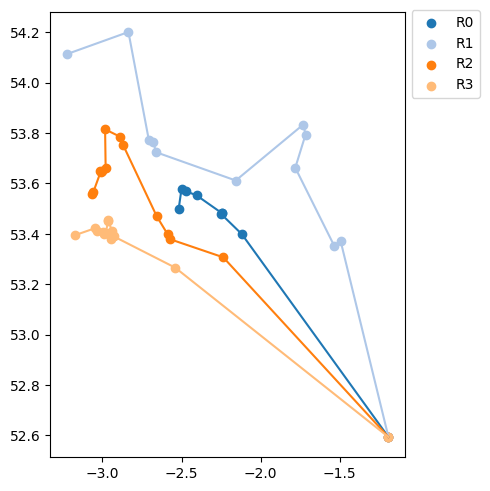

In [27]:
def route_visualize(coordinates, routes):
    coordinates = pd.DataFrame(coordinates, columns=["x", "y"])
    num_location = coordinates.shape[0]
    #
    cmap = mpl.colormaps["tab20"]
    colors = cycle(cmap.colors)
    # Now the figure
    figsize = [max(int(num_location / 8), 5), max(int(num_location / 8), 5)]
    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    for r, tour in enumerate(routes):
        c = next(colors)
        t = np.array(tour)
        x = coordinates.values[t, 0]
        y = coordinates.values[t, 1]
        ax.scatter(x, y, color=c, label=f"R{r}")
        ax.plot(x, y, color=c)

    ax.legend(loc="upper left", bbox_to_anchor=(1, 1.02))
    fig.tight_layout()
    plt.show()
    return
route_visualize(coordinates, routes[0])

In [28]:
route_pallet_delivery = []
route_weight_delivery = []
route_volume_delivery = []
route_duration = []
route_distance = []
loc_service_time = 10
for route in routes[0]:
    pallet_delivery, weight_delivery, volume_delivery= 0, 0, 0
    duration = 0
    distance = 0
    for i in range(len(route) -1):
        distance += distances[route[i]][route[i+1]]
        duration += durations[route[i]][route[i+1]] + loc_service_time
        pallet_delivery += pallets[route[i+1]]
        weight_delivery += weights[route[i+1]] 
        volume_delivery += volumes[route[i+1]]
    route_pallet_delivery.append(pallet_delivery)
    route_weight_delivery.append(weight_delivery)
    route_volume_delivery.append(volume_delivery)
    route_duration.append(duration)
    route_distance.append(distance)
print(sum(route_distance))
print(route_pallet_delivery)
print(route_weight_delivery)
print(route_volume_delivery)
print(route_duration)
print(route_distance)

1238
[22.0, 19.0, 26.0, 21.0]
[702.0, 766.0, 747.0, 1171.0]
[14.549241600000002, 17.3810976, 16.321771200000004, 16.068350400000003]
[320, 517, 441, 397]
[237, 426, 341, 234]
